# 修饰关键字
我们知道数据类型关键字的作用是告诉编译器圈定内存的大小。但实际工程应用中，只有大小的限制是不够的。想一想，我们的内存空间这么大(32位系统为例，有4G的内存寻址空间)，该从哪个地方圈定内存呢？是全部区域都可以吗?分配给你的内存空间，要不要有些操作做限定呢?这些都是需要修饰关键宁来告诉编译器该怎么来做。

## 1. register关键字
register关键字是一个建议性关键字。设计的初衷是想要定义的变量放到cpu的寄存器中，但是往往编译器看到这个关键字的时候，发出一句呐喊:臣妾做不到啊。寄存器相对于内存，Cpu在访问速度上更快，但是也很稀缺，不是说放就放的。所以编译器只能尽量的去做，他不一定能保证做到，不要太奢望了。但值得注意的是加上register修饰后的变量，无法通过&来取地址。即使大概率放进寄存器会失败，但编译器就不给你寻址，万一成功了呢?编译器还是有梦想的。
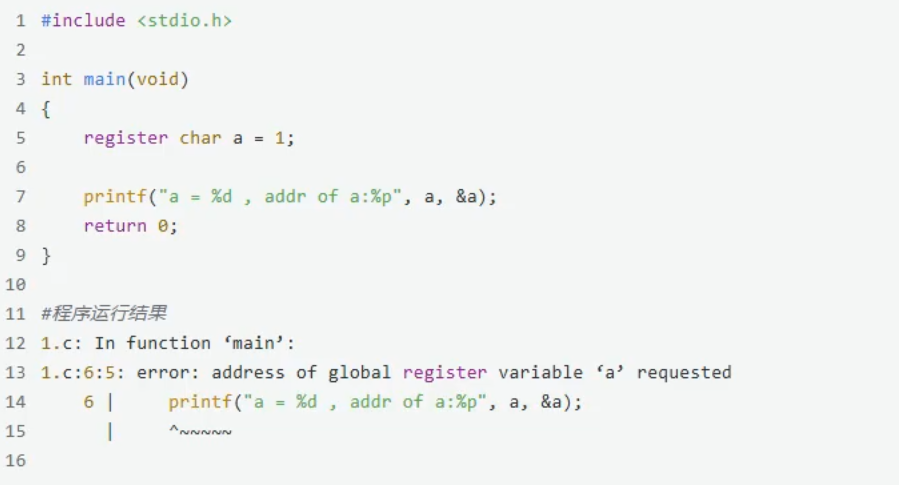

`//静态变量  在普通变量前面加static,属于静态变量，静态变量不管是全局的还是局部的，都是存储在全局区的`
## 2. static 关键字
`static` 是 C/C++ 中“身兼数职”的关键字，其作用**完全取决于它出现的位置**。核心可分为三大场景：**全局/命名空间作用域**、**局部作用域**、**类作用域**。


### 一、全局/命名空间作用域的 `static`：改变链接属性（内部链接）
当 `static` 修饰**全局变量**或**普通函数**（不在类或函数内）时，作用是将其**链接属性**从“外部链接”改为“内部链接”。 `使用习惯：如果明确某个全局变量或函数仅供当前文件使用，建议加 static 修饰以隐藏实现细节，避免命名冲突，没有加static的全局变量或函数默认可以被外部访问`。

#### 1. 核心含义
- **外部链接**（默认）：全局变量/函数可被**其他编译单元**（.cpp 文件）通过 `extern` 声明访问。
- **内部链接**（加 `static`）：全局变量/函数**仅在当前 .cpp 文件内可见**，其他文件无法访问（相当于“私有化”）。

#### 2. 示例代码
```cpp
// 文件1：main.cpp
#include <iostream>

// 声明外部变量/函数（尝试访问文件2中的内容）
extern int globalVar;        // 访问文件2的普通全局变量
extern void publicFunc();    // 访问文件2的普通函数
// extern int staticVar;     // ❌ 错误：无法访问文件2的 static 全局变量
// extern void staticFunc(); // ❌ 错误：无法访问文件2的 static 函数

int main() {
    std::cout << globalVar << std::endl; // 输出 100（成功访问）
    publicFunc();                         // 输出 "Public function called"（成功）
    return 0;
}
```

```cpp
// 文件2：utils.cpp
// 普通全局变量：外部链接，可被其他文件访问
int globalVar = 100;

// static 全局变量：内部链接，仅当前文件可见
static int staticVar = 200;

// 普通函数：外部链接
void publicFunc() {
    std::cout << "Public function called" << std::endl;
}

// static 函数：内部链接，仅当前文件可见
static void staticFunc() {
    std::cout << "Static function called" << std::endl;
}
```

#### 3. 实际用途
- **避免命名冲突**：不同文件可定义同名 `static` 变量/函数，互不干扰。
- **隐藏实现细节**：将辅助函数设为 `static`，只暴露核心接口（类似“私有函数”）。

### 二、局部作用域的 `static`：延长生命周期（静态局部变量）
当 `static` 修饰**函数内部的局部变量**时，作用是改变变量的**生命周期**（但作用域不变）。

#### 1. 核心特性
- **作用域**：仍局限于函数内部（外部无法访问）。
- **生命周期**：从“函数第一次调用时初始化”延长到**程序结束**（存储在静态存储区「本质是全局区」，而非栈区）。
- **值保留**：函数下次调用时，变量会保留上一次的值（不会重新初始化）。
- **线程安全**（C++11 起）：静态局部变量的初始化是线程安全的（“Magic Static”）。

#### 2. 示例代码（逐行解析）
```cpp
#include <iostream>

void countCalls() {
    // 普通局部变量：每次调用函数都会重新初始化为 0
    int normalVar = 0;
    
    // 静态局部变量：仅在第一次调用时初始化为 0，后续保留值
    static int staticVar = 0; 
    
    normalVar++;
    staticVar++;
    
    std::cout << "Normal: " << normalVar << ", Static: " << staticVar << std::endl;
}

int main() {
    countCalls(); // 输出 Normal: 1, Static: 1
    countCalls(); // 输出 Normal: 1, Static: 2（normalVar 重置，staticVar 保留）
    countCalls(); // 输出 Normal: 1, Static: 3
    return 0;
}
```

#### 3. 实际用途

### 三、类作用域的 `static`：类共享成员（静态成员变量/函数）
当 `static` 修饰**类的成员变量或成员函数**时，它们成为“类级别”的成员，而非“对象级别”。

---

#### 1. 静态成员变量
- **核心特性**：
  - 不属于任何对象，**所有对象共享同一份静态成员变量**（存储在静态存储区,即全局区）。
  - 必须在**类外单独初始化**（const 静态整型/枚举除外，C++17 后 `inline static` 可类内初始化）。
- **示例代码**：
```cpp
#include <iostream>

class MyClass {
public:
    static int staticVar; // 类内声明静态成员变量
    int normalVar;         // 普通成员变量（每个对象一份）
};

// 类外初始化静态成员变量（必须！否则链接错误）
int MyClass::staticVar = 0;

int main() {
    MyClass obj1;
    MyClass obj2;
    
    // 通过类名直接访问（推荐）
    MyClass::staticVar = 100;
    
    // 通过对象访问（效果相同，因为共享）
    obj1.staticVar = 200;
    std::cout << obj2.staticVar << std::endl; // 输出 200（obj2 的值也被改变）
    
    return 0;
}
```

---

#### 2. 静态成员函数
- **核心特性**：
  - 没有 `this` 指针（因为不属于对象）。
  - 只能访问**静态成员变量**和**其他静态成员函数**（无法访问非静态成员，因为非静态成员依赖 `this` 指针）。
  - 可通过类名直接调用（无需创建对象）。
- **示例代码**：
```cpp
#include <iostream>

class MyClass {
private:
    static int staticVar; // 私有静态成员变量
    int normalVar;         // 私有普通成员变量

public:
    // 静态成员函数：只能访问静态成员
    static void setStaticVar(int val) {
        staticVar = val;       // ✅ 正确：访问静态成员变量
        // normalVar = val;    // ❌ 错误：无法访问非静态成员（无 this 指针）
    }

    static int getStaticVar() {
        return staticVar;
    }
};

// 类外初始化静态成员变量
int MyClass::staticVar = 0;

int main() {
    // 无需创建对象，直接通过类名调用静态成员函数
    MyClass::setStaticVar(500);
    std::cout << MyClass::getStaticVar() << std::endl; // 输出 500
    return 0;
}
```

---

#### 3. 实际用途
- **统计对象数量**：用静态成员变量记录创建的对象个数。
- **工具类**：封装不依赖对象状态的函数（如数学计算函数）。
- **单例模式**：结合静态成员函数和静态局部变量实现。


### 四、一句话总结 `static` 的作用
| 位置               | 作用                                                                 |
|--------------------|----------------------------------------------------------------------|
| 全局/命名空间      | 改为内部链接，仅当前文件可见（避免命名冲突、隐藏实现）。           |
| 函数局部变量       | 延长生命周期至程序结束，保留值（仅第一次初始化）。                 |
| 类成员变量         | 所有对象共享，类外初始化。                                           |
| 类成员函数         | 无 `this` 指针，仅访问静态成员，可通过类名直接调用。               |

## 3. extern关键字

`extern` 是 C/C++ 中用于**跨编译单元（.cpp 文件）共享代码**的核心关键字，其核心作用是**声明一个具有外部链接属性的实体**，告诉编译器："这个变量/函数在**其他文件**中已经定义过了，你先编译，链接阶段再去找它的地址"。

它与我们之前讲的 `static` 是**完全相反**的一对关键字：
- `static`：将实体的链接属性改为**内部链接**（仅当前文件可见）
- `extern`：显式指定实体具有**外部链接**（所有文件可见）

### 一、最核心用法：声明外部全局变量/函数
`“想让一个变量 / 函数给其他文件用，在头文件里用 extern 声明，在一个源文件里定义”那我不写这个extern的话，我只要包含这个函数或者变量所在的头文件，不也一样可以调用，有什么区别吗？：` 

`「核心原因是：函数的声明和定义有天然的语法区分，而变量没有。头文件的本质是 "代码复制粘贴"，不加 extern 的变量会在每个包含它的文件中都生成一份定义，直接导致链接错误。」`

#### 1. 关键概念：声明 vs 定义
这是理解 `extern` 的前提：
- **定义**：为变量分配内存空间，可以初始化。一个变量/函数在整个程序中**只能有一个定义**（ODR 原则：单一定义原则）。
- **声明**：告诉编译器变量/函数的类型和名字，**不分配内存**。一个变量/函数可以有多个声明。

`extern` 只做**声明**，不做定义（除非显式初始化）。

#### 2. 基本语法与示例
```cpp
// 声明外部变量
extern 类型 变量名;

// 声明外部函数
extern 返回类型 函数名(参数列表);
// 注：函数声明默认就是 extern，所以可以省略 extern
```

**完整跨文件示例**：
```cpp
// 文件1：global.cpp（定义全局变量和函数）
int global_count = 0;  // 定义：分配内存并初始化

void print_count() {   // 定义：函数体就是定义
    std::cout << "Count: " << global_count << std::endl;
}
```

```cpp
// 文件2：main.cpp（声明并使用外部变量和函数）
#include <iostream>

// 声明：告诉编译器 global_count 在其他文件定义
extern int global_count;

// 声明外部函数（extern 可省略，函数声明默认外部链接）
void print_count();

int main() {
    global_count = 100;  // 使用外部变量
    print_count();       // 调用外部函数，输出 "Count: 100"
    return 0;
}
```

#### 3. 常见坑点（⚠️ 重点）
##### 坑1：头文件中定义全局变量导致重复定义
**错误写法**：
```cpp
// common.h（头文件）
int error_var = 10;  // ❌ 头文件中定义全局变量
```
如果多个 `.cpp` 文件包含这个头文件，每个文件都会生成一份 `error_var` 的定义，链接时会报"多重定义"错误。

**正确写法**：
```cpp
// common.h（头文件）
extern int correct_var;  // ✅ 只做声明
```

```cpp
// common.cpp（源文件）
int correct_var = 10;  // ✅ 唯一的定义
```

##### 坑2：extern 声明的变量没有定义
如果只写了 `extern int x;`，但在任何文件中都没有 `int x;` 的定义，链接时会报"未定义的引用"错误。

##### 坑3：extern 加初始化会变成定义
```cpp
extern int x = 10;  // ❌ 这是定义，不是声明！
// 等价于 int x = 10; 会分配内存，多个文件包含会重复定义
```



### 二、C++ 专属：`extern "C"` 解决链接兼容性问题
这是 C++ 中 `extern` 最常用的进阶用法，**解决 C++ 与 C 代码混合编译时的函数名不匹配问题**。

#### 1. 问题根源：C++ 的名字修饰（Name Mangling）
C++ 支持函数重载，编译器会对函数名进行"修饰"（加入参数类型信息）来区分不同的重载函数。例如：
- C 编译器会将 `void func(int)` 编译为 `_func`
- C++ 编译器会将 `void func(int)` 编译为 `_Z4funci`，将 `void func(double)` 编译为 `_Z4funcd`

如果 C++ 代码直接调用 C 函数，或者 C 代码调用 C++ 函数，会因为函数名不匹配导致链接错误。

#### 2. `extern "C"` 的作用
告诉 C++ 编译器："按照 C 语言的规则来编译这段代码，不要进行名字修饰"。

#### 3. 标准用法
```cpp
#ifdef __cplusplus
extern "C" {
#endif

// 这里面的所有函数和全局变量都会按照 C 方式编译
void c_function(int a);
int c_global_var;

#ifdef __cplusplus
}
#endif
```

**为什么要加 `#ifdef __cplusplus`？**
因为 C 编译器不认识 `extern "C"` 这个语法，所以只在 C++ 编译时才展开这段代码。

#### 4. 典型应用场景
- C++ 项目中调用 C 语言编写的库（如标准 C 库、第三方 C 库）
- C 项目中调用 C++ 编写的函数（需要将 C++ 函数用 `extern "C"` 包裹）

---

### 三、与 `static` 的核心对比
| 关键字 | 链接属性 | 可见范围 | 定义位置 | 用途 |
|--------|----------|----------|----------|------|
| `static` | 内部链接 | 仅当前编译单元可见 | 全局/函数内/类内 | 避免命名冲突、隐藏实现、静态局部变量、类静态成员 |
| `extern` | 外部链接 | 所有编译单元可见 | 全局 | 跨文件共享变量/函数、C/C++ 混合编译 |

**一句话总结**：
- 想让一个变量/函数**只在自己文件里用**，加 `static`
- 想让一个变量/函数**给其他文件用**，在头文件里用 `extern` 声明，在一个源文件里定义

---

### 四、其他进阶用法（了解即可）
1. **extern 模板实例化**（C++11 起）：
   ```cpp
   // 显式实例化声明，告诉编译器模板在其他文件实例化
   extern template class std::vector<int>;
   ```
   可以减少编译时间，避免每个文件都实例化相同的模板。

2. **extern thread_local**（C++11 起）：
   声明一个线程局部的外部变量，每个线程有自己独立的副本。

需要我进一步解释**链接阶段的工作原理**，或者给你一个完整的**C/C++ 混合编译项目示例**吗？

### 总结
- 在架构设计的时候尽量不要用 extern 来暴露全局变量和函数，除非确实需要跨文件共享，否则建议使用类的静态成员或者单例模式来管理全局状态，保持代码的封装性和可维护性。在c中，可以使用static关键字，然后封装访问的入口函数来管理全局状态，避免直接暴露全局变量。
```c
//1.c
#include <stdio.h>
#include "2.h"
int main(void)
{
    set_a(20);
    printf("a - %d\n", read_a());
    return 0;
}
//2.h
void set_a(int value);
int read_a(void);
//2.c
static int a = 10;
void set_a(int value)
{
    mutex_lock();
    a = value;
    mutex_unlock();
}
int read_a(void)
{
    return a;
}
```

## 4. const关键字

`const` 是 C/C++ 中**最常用也最容易被误解**的关键字之一，其核心作用是**强制实现"只读"语义**，通过编译器检查来保证数据不被意外修改。它不仅能提高代码的**类型安全性**和**可读性**，还能帮助编译器进行更激进的**代码优化**。

`const` 的作用完全取决于它**修饰的对象**和**出现的位置**，下面按场景逐一解析。

---

### 一、修饰普通变量：将变量变为只读常量
这是 `const` 最基础的用法，将一个变量声明为"只读"，一旦初始化就不能再修改。

#### 1. 基本语法
```cpp
const 类型 变量名 = 初始值;
// 等价于
类型 const 变量名 = 初始值;
```
- 两种写法完全等价，推荐第一种（`const` 在前），更符合阅读习惯。

#### 2. 示例代码
```cpp
#include <iostream>

int main() {
    const int MAX_SIZE = 100; // 声明为只读常量
    // MAX_SIZE = 200; // ❌ 编译错误：不能修改const变量
    
    int arr[MAX_SIZE]; // ✅ C++中可以用const常量定义数组大小（C语言不行）
    
    std::cout << MAX_SIZE << std::endl; // 输出 100
    return 0;
}
```

#### 3. 关键特性
- **必须初始化**：`const` 变量在声明时必须赋值，否则编译错误。
- **编译期常量**：如果用字面量初始化，编译器通常会将其视为编译期常量，直接在代码中替换为对应的值（类似宏定义，但有类型安全）。
- **存储位置**：全局 `const` 变量通常存储在**只读数据段**（.rodata），修改会导致程序崩溃；局部 `const` 变量可能存储在栈上，但编译器会阻止修改。

### 二、修饰指针和引用：最容易混淆的用法
这是 `const` 最容易出错的部分，核心是区分**const修饰的是指针本身，还是指针指向的内容**。

#### 1. 四种情况对比表
| 语法 | 含义 | 能否修改指针本身 | 能否修改指向的内容 |
|------|------|------------------|--------------------|
| `const int* p;` | 指向**const int**的指针（指针可变，内容不可变） | ✅ 可以指向其他地址 | ❌ 不能修改 *p |
| `int* const p;` | **const指针**指向int（指针不可变，内容可变） | ❌ 不能指向其他地址 | ✅ 可以修改 *p |
| `const int* const p;` | **const指针**指向**const int**（都不可变） | ❌ 不能指向其他地址 | ❌ 不能修改 *p |
| `int const* p;` | 等价于 `const int* p;` | ✅ | ❌ |

#### 2. 记忆口诀
**"左定值，右定指"**
- `const` 在 `*` **左边**：修饰的是**指向的内容**（值），内容不可变
- `const` 在 `*` **右边**：修饰的是**指针本身**，指针不可变

#### 3. 示例代码
```cpp
#include <iostream>

int main() {
    int a = 10, b = 20;
    
    // 1. 指向const的指针：内容不可变，指针可变
    const int* p1 = &a;
    // *p1 = 100; // ❌ 错误：不能修改指向的内容
    p1 = &b;       // ✅ 正确：可以改变指针指向
    
    // 2. const指针：指针不可变，内容可变
    int* const p2 = &a;
    *p2 = 100;     // ✅ 正确：可以修改指向的内容
    // p2 = &b;    // ❌ 错误：不能改变指针指向
    
    // 3. 都不可变
    const int* const p3 = &a;
    // *p3 = 200;  // ❌ 错误
    // p3 = &b;    // ❌ 错误
    
    return 0;
}
```

#### 4. const引用
引用本质上是"变量的别名"，`const` 引用表示"不能通过这个引用修改原变量"。
```cpp
int a = 10;
const int& ref = a; // const引用
// ref = 20; // ❌ 错误：不能通过const引用修改a
a = 20;       // ✅ 正确：可以直接修改原变量
```
**重要用途**：函数参数传递时，用 `const T&` 传递大对象，既避免拷贝开销，又保证原对象不被修改。


### 三、修饰函数参数：保证参数不被修改
这是 `const` 最常用的场景之一，用于函数参数传递，明确告诉调用者"这个函数不会修改你传入的参数"。

#### 1. 按值传递：没必要加const
```cpp
void func(int x); // 按值传递，函数操作的是副本，加const无意义
```
因为函数操作的是参数的副本，修改不会影响原变量，所以加 `const` 没有实际价值。

#### 2. 按指针/引用传递：强烈建议加const
```cpp
// 传递大对象时，用const引用避免拷贝，同时保证不修改原对象
void printString(const std::string& str) {
    // str = "hello"; // ❌ 错误：不能修改const引用参数
    std::cout << str << std::endl;
}

// 传递数组时，用const指针保证数组内容不被修改
void printArray(const int* arr, int size) {
    for (int i = 0; i < size; ++i) {
        std::cout << arr[i] << " ";
    }
}
```

### 3. 实际意义
- **自我文档化**：一眼就能看出函数是否会修改参数
- **编译器检查**：防止函数内部意外修改参数
- **扩大适用范围**：可以接受const对象作为参数（非const参数不能接受const对象）

### 四、修饰函数返回值：防止返回值被修改
当函数返回指针或引用时，用 `const` 修饰返回值可以防止返回值被意外修改。

#### 1. 示例代码
```cpp
class MyClass {
private:
    int data;
public:
    MyClass(int d) : data(d) {}
    
    // 返回const引用：防止外部修改私有成员
    const int& getData() const {
        return data;
    }
};

int main() {
    MyClass obj(100);
    
    // int& ref = obj.getData(); // ❌ 错误：不能将const引用转换为非const引用
    const int& ref = obj.getData(); // ✅ 正确
    // ref = 200; // ❌ 错误：不能修改const引用
    
    std::cout << obj.getData() << std::endl; // 输出 100
    return 0;
}
```

#### 2. 适用场景
- 函数返回类的私有成员的引用/指针时
- 函数返回的临时对象不应该被修改时


### 五、类中的const：const成员函数
这是 C++ 特有的用法，也是面向对象编程中非常重要的特性。

#### 1. const成员函数的声明
```cpp
class MyClass {
public:
    // 在函数参数列表后加const，表示这是一个const成员函数
    void func() const {
        // 不能修改任何非mutable成员变量
    }
};
```

#### 2. 核心含义
- `const` 成员函数**不能修改类的任何非mutable成员变量**
- `const` 成员函数**只能调用其他const成员函数**
- `const` 对象**只能调用const成员函数**，不能调用非const成员函数

#### 3. 底层原理
成员函数有一个隐含的 `this` 指针，`const` 成员函数的 `this` 指针类型是 `const T*`（指向const对象的指针），因此不能通过 `this` 指针修改成员变量。

#### 4. mutable关键字
如果需要在 `const` 成员函数中修改某个成员变量，可以用 `mutable` 修饰该变量：
```cpp
class MyClass {
private:
    mutable int callCount; // mutable成员变量可以在const函数中修改
    int data;
public:
    MyClass(int d) : data(d), callCount(0) {}
    
    int getData() const {
        callCount++; // ✅ 正确：mutable变量可以修改
        return data;
    }
};
```
**典型用途**：统计const成员函数的调用次数、缓存计算结果等。


### 六、常见误区和最佳实践
#### 1. 常见误区
- **误区1**：`const` 变量的值一定不能改变
  - 可以通过指针强制转换绕过编译器检查，但这是未定义行为，绝对不要这么做
- **误区2**：`const` 成员函数不能修改任何成员变量
  - 可以修改 `mutable` 修饰的成员变量
- **误区3**：`#define` 和 `const` 一样
  - `#define` 是宏定义，没有类型安全，只是简单的文本替换；`const` 是真正的变量，有类型检查

#### 2. 最佳实践
- **能用const的地方尽量用const**：这是C++编码的黄金法则
- 函数参数传递大对象时，优先使用 `const T&`
- 不修改成员变量的成员函数，一定要声明为 `const`
- 编译期能确定的常量，优先使用 `constexpr` 而不是 `const`
- 不要在头文件中定义非 `const` 全局变量（会导致多重定义）

#### 3. const和宏的区别
const设计的初衷就是为了代替宏，消除它的缺点，继承它的优点。
- 1.编译器处理方式:define宏是在预处理阶段展开;const变量是编译运行阶段使用
- 2.安全检查:define宏不做任何类型检查，仅仅是展开;const变量编译阶段会执行类型检查
- 3.内存位置:define宏在代码段;const常量可以在静态全局数据段、栈中

### 七、一句话总结
`const` 的核心是**"只读"语义**，它通过编译器强制保证数据不被意外修改，提高代码的安全性、可读性和可维护性。从普通变量到指针、函数、类，再到现代C++的编译期常量，`const` 贯穿了C++编程的方方面面。


## 5. volatile 关键字
volatile关键字用于告诉编译器，被声明为volatile的变量的值可能在程序的控制之外发生变化，因此编译器不应该对其进行某些优化。主要用于处理硬件寄存器、中断服务程序和多线程等情况:下面如果buff变量是uart的DR寄存器映射，即使代码中没有地方更新buff的值，也应该告诉编译器不要优化，如果有地方读取buff值的时候，都需要从内存中读取，因为外部uart会触发更新。
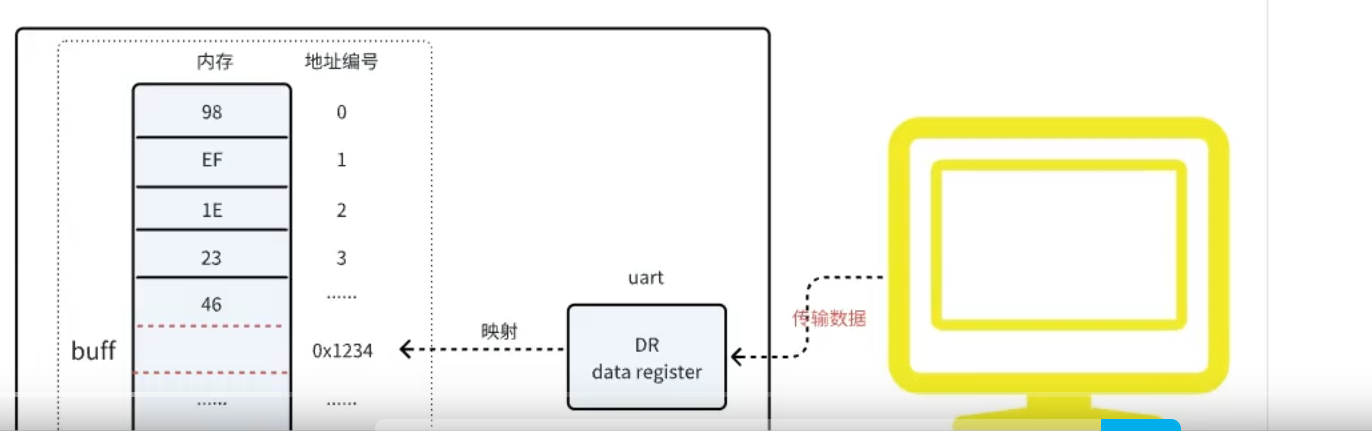

In [ ]:
#include <stdio.h>

/*unsigned char buff;
编译器会扫描整个main函数的控制流，发现没有任何一行代码修改buff的值。因此它会得出一个错误的结论：buff的值在整个程序运行期间是恒定的。
基于 "buff 值不变" 的错误结论，编译器会：
寄存器缓存优化：只在第一次使用buff时从内存读取一次，将其值存入 CPU 寄存器，之后所有对buff的访问都直接使用寄存器中的值，再也不会访问内存。
循环不变量外提：把循环中不变的条件判断提到循环外面，避免每次循环都重复计算。
*/
volatile unsigned char buff;
int main(){
    while(buff){

    }
    return 0;
}

### 核心原理：编译器优化逻辑
编译器默认判定：**变量仅当前代码读写，值不会意外变动**，会做寄存器缓存优化。

1. **无volatile时**
变量读取一次后，值存入CPU寄存器，后续重复读取直接拿寄存器数据，不再访问内存/硬件地址。
外部硬件、中断、其他任务改了内存原值，当前代码感知不到，数据失效。

2. **加volatile后**
强制禁止缓存优化，**每次读写都直接操作物理内存地址**，实时获取最新真实值。

#### 场景具象解释
##### 1. 硬件寄存器
寄存器属于物理外设地址，硬件会自主改写数值。编译器看不到硬件动作，无优化限制就会省略重复读操作，导致读不到实时状态。

##### 2. 中断共享变量
中断是异步触发，不属于主流程代码执行顺序。编译器预判不到中断修改变量，会把变量常驻寄存器，主循环检测不到数值变化。

##### 3. 多任务共享
任务切换由系统调度，代码执行顺序不可预判。缓存值无法同步其他任务的修改，数据出现偏差。

##### 关键补充
volatile只解决**读取实时性**，**不保障原子操作**。多线程频繁读写仍需关中断、互斥锁防护。

# 位运算符

## 1. 移位运算符：<< 和 >>

### 1.1 "<<"左移:在没有溢出之前，每移动一位等价于乘于2，且移位后右边补0;
`所有位运算都直接在补码上进行，和原码没有任何关系`

In [ ]:
#include <stdio.h>
#define CALCULATE_LEN(a) (sizeof(a)*8)
/* #define CALCULATE_LEN(a) (sizeof(a)*8)：定义一个宏，计算变量 a 的总位数。
sizeof(a)：得到变量 a 占用的字节数（比如 char 是 1 字节）。
*8：1 字节 = 8 位，所以总位数 = 字节数 ×8。*/
void print_binary(long long a, int n)
{/* 用long long 为了防止位移运算时数据溢出、高位丢失，保证二进制打印绝对准确。
int 只有 32 位，移位容易溢出
char 8 位
int 32 位
long long 64 位
你做的是左移 / 右移运算，如果用 int：
移 32 位 → 直接溢出、数据错乱
移超过 32 位 → C 语言标准规定：结果未定义（随机值）
. 函数要通用，支持所有类型*/
    printf(": ");
    while (n--) {
        printf("%lld ", (a >> n) & 0x01);
        /*核心逻辑拆解：
while (n--)：循环 n 次，从最高位到最低位依次处理。
(a >> n) & 0x01：这是提取某一位二进制值的经典技巧：
a >> n：把 a 右移 n 位，这样原来的第 n 位就会移动到最低位（第 0 位）。
& 0x01：0x01 是二进制 00000001，按位与操作会把除最低位以外的所有位清零，只保留最低位的值（0 或 1）。
printf("%lld ", ...)：把提取到的每一位（0 或 1）打印出来，用空格分隔。
最后 printf(": %lld \n", a);：打印 a 的十进制值，方便对照。

//a >> n 是表达式，只会计算出一个新的临时值，原变量 a 本身纹丝不动。
只有当你使用复合赋值运算符 >>= 时，才会修改原变量：
        */
    }
    printf(": %lld \n", a);//%lld 是 long long 类型的格式说明符
}
void main(void)
{
    char a = 1;
    for (int i = 0; i < 8; i++) {
        printf("%d left shift %d ", a, i);
        print_binary(a << i, CALCULATE_LEN(a));
    }
}

程序运行结果

| 序号 | 语句               | 二进制结果 | 十进制结果 | 说明                     |
|-----:|:-------------------|:----------:|-----------:|:-------------------------|
|    1 | a=1, left shift 0  |  00000001  |          1 | 左移 0 位，值不变，1×2⁰=1 |
|    2 | a=1, left shift 1  |  00000010  |          2 | 左移 1 位，1×2¹=2        |
|    3 | a=1, left shift 2  |  00000100  |          4 | 左移 2 位，1×2²=4        |
|    4 | a=1, left shift 3  |  00001000  |          8 | 左移 3 位，1×2³=8        |
|    5 | a=1, left shift 4  |  00010000  |         16 | 左移 4 位，1×2⁴=16       |
|    6 | a=1, left shift 5  |  00100000  |         32 | 左移 5 位，1×2⁵=32       |
|    7 | a=1, left shift 6  |  01000000  |         64 | 左移 6 位，1×2⁶=64       |
|    8 | a=1, left shift 7  |  10000000  |        128 | 左移 7 位，1×2⁷=128      |
|    9 | a=1, left shift 8  |  00000000  |          0 | 左移 8 位，溢出了！       |



### 1.2 ">>"右移:每移动一位等价于除于2,signed类型和unsigned在右移的时候有差别:如果是负数，移位后左边补1，正数补0，所以负数通过右移永远都不会等于0:

- 为什么「signed类型和unsigned在右移的时候有差别:如果是负数，移位后补1，正数补0，所以负数通过右移永远都不会等于0:」？
  
这是位运算中最容易踩坑的核心知识点，本质是计算机负数的存储方式和算术右移的设计目的共同决定的。
- 一、先搞懂两个前置知识（缺一不可）
1. 所有负数在计算机中都以「补码」存储
这是整个问题的根源。计算机没有 "正负号" 的硬件概念，只能用 0 和 1，所以规定：
最高位是符号位：0 = 正数，1 = 负数
正数的补码 = 原码（比如 1=00000001）
负数的补码 = 原码取反 + 1（这是关键！）
举个 8 位有符号整数的例子：

| 类型             | 右移方式   | 空位填充规则                     | 适用场景                               |
|------------------|------------|----------------------------------|----------------------------------------|
| unsigned（无符号）| 逻辑右移   | 永远补 0                         | 纯二进制位操作                         |
| signed（有符号）  | 算术右移   | 补符号位（正数补 0，负数补 1）   | 保持数值符号，实现数学上的 "除以 2"     |

⚠️ 重点：你看到的所有位运算，都是直接操作补码，不是原码！
1. 右移分两种：算术右移 vs 逻辑右移
这就是signed和unsigned的本质区别：
表格
类型	右移方式	空位填充规则	适用场景
unsigned（无符号）	逻辑右移	永远补 0	纯二进制位操作
signed（有符号）	算术右移	补符号位（正数补 0，负数补 1）	保持数值符号，实现数学上的 "除以 2"
- 二、为什么负数右移永远不会等于 0？
核心结论：
因为算术右移永远补符号位（1），所以最高位永远是 1，所有位永远不可能全变成 0。

In [ ]:
#include <stdio.h>
// 计算变量的二进制位数（字节数×8）
#define CALCULATE_LEN(a) (sizeof(a)*8)
// 打印一个数的二进制表示（从最高位到最低位）
void print_binary(char a, int n)
{
    printf(": ");
    while (n--) {
        //%d是int类型说明符，%o是八进制，%x是十六进制，因为没有二进制输出的标准库，所以下面可以这样写
        // 先右移n位，再和0x01与运算，取出第n位的值
        printf("%d ", (a >> n) & 0x01);
    }
    printf(": %d \n", a);
}

int main(void)  
{
    // 测试1：有符号char类型（默认char在多数编译器是signed）
    char a = 0x80;  // 0x80 = 10000000，有符号char中等于-128
    printf("=== 程序运行结果：a 为 char 类型（有符号） ===\n");
    for (int i = 0; i < 9; i++) {
        // a & 0xFF 是为了正确打印十六进制（避免符号扩展成0xffffff80）
        printf("a = 0x%x, right shift %d times", a & 0xFF, i);
        print_binary((a >> i), CALCULATE_LEN(a));
    }

    // 测试2：无符号unsigned char类型（对比用）
    unsigned char b = 0x80;  // 无符号char中0x80等于128
    printf("\n=== 程序运行结果：a 为 unsigned char 类型（无符号） ===\n");
    for (int i = 0; i < 9; i++) {
        printf("a = 0x%x, right shift %d times", b, i);
        // 注意：这里要把unsigned char转成char传给print_binary（不影响二进制位）
        print_binary((char)(b >> i), CALCULATE_LEN(b));
    }

    return 0;
}

程序运行结果

有符号char（signed char）右移结果表
| 序号 | 右移次数 | 二进制结果     | 十进制结果 |
|---:|---------:|:--------------:|-----------:|
| 1    | 0        | 1 0 0 0 0 0 0 0 | -128       |
| 2    | 1        | 1 1 0 0 0 0 0 0 | -64        |
| 3    | 2        | 1 1 1 0 0 0 0 0 | -32        |
| 4    | 3        | 1 1 1 1 0 0 0 0 | -16        |
| 5    | 4        | 1 1 1 1 1 0 0 0 | -8         |
| 6    | 5        | 1 1 1 1 1 1 0 0 | -4         |
| 7    | 6        | 1 1 1 1 1 1 1 0 | -2         |
| 8    | 7        | 1 1 1 1 1 1 1 1 | -1         |
| 9    | 8        | 1 1 1 1 1 1 1 1 | -1         |

无符号char（unsigned char）右移结果表

| 序号 | 右移次数 | 二进制结果     | 十进制结果 |
|---:|---------:|:--------------:|-----------:|
| 1    | 0        | 1 0 0 0 0 0 0 0 | 128        |
| 2    | 1        | 0 1 0 0 0 0 0 0 | 64         |
| 3    | 2        | 0 0 1 0 0 0 0 0 | 32         |
| 4    | 3        | 0 0 0 1 0 0 0 0 | 16         |
| 5    | 4        | 0 0 0 0 1 0 0 0 | 8          |
| 6    | 5        | 0 0 0 0 0 1 0 0 | 4          |
| 7    | 6        | 0 0 0 0 0 0 1 0 | 2          |
| 8    | 7        | 0 0 0 0 0 0 0 1 | 1          |
| 9    | 8        | 0 0 0 0 0 0 0 0 | 0          |

### 1.3 按位与、或、取反:&、|、~
我们知道操作硬件的最小能力是bit位，所以按位与“&”、按位或“|”、按位取反”~”在嵌入式的寄存器操作中运用非常广泛，下面是基本规则:

|: 1 | 1 = 1; 1 | 0 = 1; 0 | 1 = 1; 0 | 0 = 0   按位或->俗称置位器(set)

&: 1 & 1 = 1; 1 & 0 = 0; 0 & 1 = 0; 0 & 0 = 0   按位与->俗称消零器 (clr)

~: ~(0x80)=0x7F  0b10000000 ~0b01111111               ->按位取反

#### 1.3.1 按位或| 给某一位置位
`#define SET(reg, n) ((reg) |= 0x1 << (n))`

In [ ]:
#include <stdio.h>

// 计算变量的二进制位数（字节数×8）
#define CALCULATE_LEN(a) (sizeof(a)*8)

// 核心宏：将寄存器reg的第n位设置为1（位操作最常用的宏）
// 原理：1左移n位得到目标位为1的掩码，与原数做按位或运算
#define SET(reg, n) ((reg) |= 0x1 << (n))

// 打印无符号字符的二进制表示（已修复之前的符号转换问题）
void print_binary(unsigned char a, int n)
{
    printf(": ");
    while (n--) {
        // 右移n位后与0x01与，取出第n位的值（从最高位到最低位打印）
        printf("%d ", (a >> n) & 0x01);
    }
    printf(": %d \n", a);
}

int main(void)
{
    // 初始值：二进制 00000001，十进制 1
    unsigned char a = 0x01;
    
    printf("a");
    print_binary(a, CALCULATE_LEN(a));

    // 以下三种写法完全等价，都是将第7位（最高位）设置为1
    // a = a | 0x80;        // 直接用十六进制掩码
    // a = a | 0x1 << 7;    // 手动计算掩码
    SET(a, 7);               // 用宏封装，可读性最好

    printf("a");
    print_binary(a, CALCULATE_LEN(a));

    return 0;
}

程序运行结果

a: 0 0 0 0 0 0 0 1 : 1 

a: 1 0 0 0 0 0 0 1 : 129 

#### 1.3.2 按位与&和~ 给某一位消零
`#define CLR(reg, n) ((reg) &= ~(0x1 << (n)))`

In [ ]:
#include <stdio.h>

// 计算变量的二进制位数（字节数×8）
#define CALCULATE_LEN(a) (sizeof(a)*8)

// 核心宏：将寄存器reg的第n位清零（位操作第二常用宏）
// 原理：生成只有第n位为0的掩码，与原数做按位与运算
#define CLR(reg, n) ((reg) &= ~(0x1 << (n)))

// 打印无符号字符的二进制表示
void print_binary(unsigned char a, int n)
{
    printf(": ");
    while (n--) {
        printf("%d ", (a >> n) & 0x01);
    }
    printf(": %d \n", a);
}

int main(void)
{
    // 初始值：二进制 10000001，十进制 129
    unsigned char a = 0x81;//0b10000001；
    
    printf("a");
    print_binary(a, CALCULATE_LEN(a));

    // 以下三种写法完全等价，都是将第7位（最高位）清零
    // a = a & 0x7F;        // 直接用十六进制掩码//0x7F = 01111111
    // a = a & ~(0x1 << 7); // 手动计算掩码// 注意：~(0x1 << 7) = ~(0b10000000) = 0b01111111
    CLR(a, 7);               // 用宏封装，可读性最好

    printf("a");
    print_binary(a, CALCULATE_LEN(a));

    return 0;
}

程序运行结果

a: 1 0 0 0 0 0 0 1 : 129 

a: 0 0 0 0 0 0 0 1 : 1 

### 1.4 按位异或: ^ (xor)
按位异或的规则是：相同为0，不同为1，所以它的一个重要特性就是：`a ^ a = 0`，`a ^ 0 = a`，因此它可以用来**交换两个变量的值**，而不需要额外的临时变量。

⚠️ 实际开发建议：优先使用临时变量交换。异或交换更多是位运算的经典面试题，实际工程中几乎不会使用，因为可读性差且没有性能优势。

In [ ]:
#include <stdio.h>

// 不需要第三个变量，使用按位异或实现两个整数交换
void swap(int* a, int* b)
{
    // 关键：如果两个变量值相等，直接返回，否则会被清零
    if ((*a) == (*b)) {
        return;
    }

    *a = (*a) ^ (*b);
    *b = (*a) ^ (*b);
    *a = (*a) ^ (*b);
}

int main(void)
{
    int x = 3, y = 5;
    printf("交换前：x = %d, y = %d\n", x, y);
    
    swap(&x, &y);
    printf("交换后：x = %d, y = %d\n", x, y);

    // 测试相同值的情况
    int m = 10, n = 10;
    printf("\n相同值交换前：m = %d, n = %d\n", m, n);
    
    swap(&m, &n);
    printf("相同值交换后：m = %d, n = %d\n", m, n);

    return 0;
}